In [1]:
import numpy as np
import torch
import matplotlib as plt
import seaborn
from monai.transforms import LoadImaged, Compose
import json


In [2]:
# dataPath = "/project/nr_dose_scratch/training"
dataPath = "/scratch/nr_dose/training"
sample = "1ABB011" 

In [3]:
transforms = Compose([
    LoadImaged(keys=["ct"], image_only=False),
])

B = 0
R = 0
L = 0
# sample_dict = {"gt_dose": f"{dataPath}/{sample}/dose/Dose_B{B}_R{R}_L{L}.mha"}
sample_dict = {"ct": f"{dataPath}/{sample}/image/ct.mha"}
print(f"Loading ct from {sample_dict['ct']}")
data = transforms(sample_dict)
img,metadata = data["ct"], data["ct_meta_dict"]

Loading ct from /scratch/nr_dose/training/1ABB011/image/ct.mha


In [12]:
print(data["ct_meta_dict"])
for k in data.keys():
    print(f"{k}")

{'Modality': 'MET_MOD_UNKNOWN', 'spacing': array([1., 1., 3.]), original_affine: array([[  -1.,    0.,    0.,  264.],
       [   0.,   -1.,    0.,  255.],
       [   0.,    0.,    3., -141.],
       [   0.,    0.,    0.,    1.]]), space: RAS, affine: tensor([[  -1.,    0.,    0.,  264.],
        [   0.,   -1.,    0.,  255.],
        [   0.,    0.,    3., -141.],
        [   0.,    0.,    0.,    1.]], dtype=torch.float64), spatial_shape: array([495, 493,  94]), original_channel_dim: nan, 'filename_or_obj': '/scratch/nr_dose/training/1ABB011/image/ct.mha'}
ct
ct_meta_dict


In [ ]:
params = json.load(open(f"{dataPath}/beam_parameters.json"))

torch.Size([495, 493, 94])


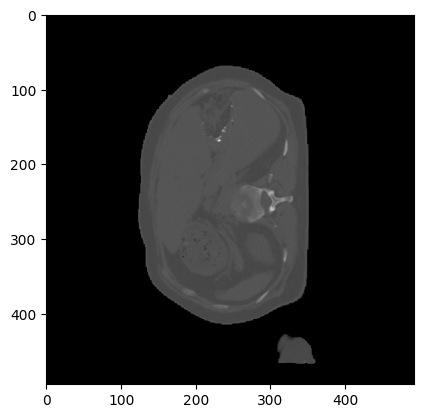

In [10]:
import matplotlib.pyplot as plt
print(img.shape)
plt.imshow(img[:,:,47], cmap='gray')
plt.show()

In [16]:
img_flat = torch.flatten(img)

In [24]:
img[img<-1000]

metatensor([-1024., -1024., -1024.,  ..., -1024., -1024., -1024.])

In [17]:
print(img_flat.shape)

torch.Size([22939290])


<Axes: ylabel='Count'>

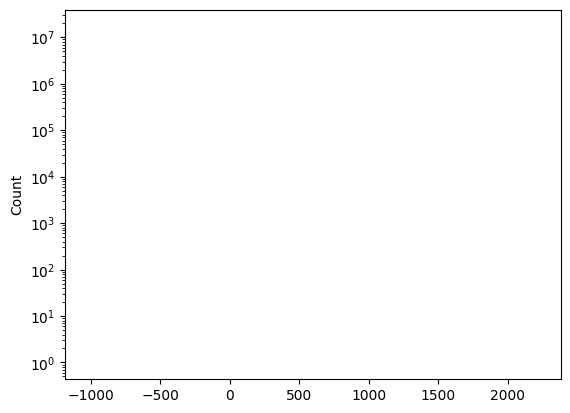

In [21]:
seaborn.histplot(img_flat, log_scale=(False, True),bins=200)

In [22]:
img_flat_unique =img_flat.unique()
print(f'img contains {len(img_flat_unique)} unique values between {img_flat_unique.min()} and {img_flat_unique.max()}')

img contains 5308762 unique values between -1024.0 and 2217.91943359375


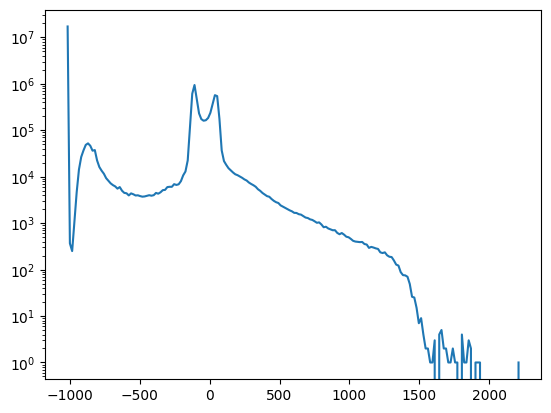

In [25]:
y, x = np.histogram(img_flat.numpy(), bins=200)
x = (x[1:] + x[:-1]) / 2
plt.plot(x, y)
plt.yscale('log')